<a href="https://colab.research.google.com/github/86HenriqueSilva/Challenge-Telecom-_X/blob/main/Challenge_Telecon_x_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⚙️ 1. Setup de Ambiente e Ingestão de Dados (Data Ingestion)

Objetivo: Preparar o ambiente de execução do Google Colab, importar as bibliotecas essenciais de análise e Machine Learning, e realizar o download seguro do dataset tratado diretamente do Google Drive.

🛠️ Boas Práticas (Clean Code e Engenharia) Aplicadas nesta etapa:

    Gestão Dinâmica de Dependências: O comando !pip install -q garante que as bibliotecas não-nativas do Colab (imbalanced-learn para balanceamento SMOTE e gdown para download do Drive) sejam instaladas de forma silenciosa, sem poluir a tela com logs de instalação.

    Observabilidade (Logging): Em vez de utilizar apenas print() soltos, configuramos a biblioteca logging. Em ambientes de produção (como fluxos automatizados em nuvem), os logs são fundamentais para rastrear onde o pipeline começou, onde terminou e onde falhou durante a madrugada.

    Programação Defensiva (Caching Local): A função de download utiliza os.path.exists() para verificar se o arquivo CSV já está na máquina virtual. Se o Colab reiniciar o kernel (memória RAM) mas mantiver o disco rígido intacto, o código é inteligente o suficiente para pular o download, economizando tempo e banda de rede.

    Tratamento de Exceções (Try/Except): O processo de extração de dados envolve a internet, que é inerentemente instável. O bloco try...except blinda o script: se o link do Drive quebrar ou a rede cair, ele emite um alerta de erro claro (logging.error) e interrompe a execução com segurança (raise), evitando que o restante do código tente rodar com uma base de dados vazia.

    Type Hinting e Docstrings: A função foi construída com anotações de tipo (ex: -> pd.DataFrame) e documentação interna padrão. Isso permite que outros programadores (ou a sua própria IDE, como o VS Code) saibam exatamente o que a função exige e o que ela devolve, facilitando a manutenção futura.

In [34]:
# ==============================================================================
# CÉLULA 1: SETUP, IMPORTAÇÕES E INGESTÃO DE DADOS
# Objetivo: Preparar o ambiente e carregar os dados de forma segura.
# ==============================================================================

# 1. Instalação de bibliotecas externas (executa silenciosamente com -q)
!pip install imbalanced-learn gdown -q

# 2. Importações Nativas e de Terceiros
import os
import logging
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importações Específicas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Configuração do nível de logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

# --- CONSTANTES GLOBAIS ---
FILE_ID = "1inOIT6WVF2Xi_dCUc57ep4eAZngzHjzm"
ARQUIVO_LOCAL = "TelecomX_Final_Limpo_v2.csv"

# --- FUNÇÕES ---
def baixar_e_carregar_dados(file_id: str, nome_arquivo: str) -> pd.DataFrame:
    """
    Faz o download do dataset via Google Drive (se necessário) e o carrega na memória.

    Args:
        file_id (str): ID público do arquivo no Google Drive.
        nome_arquivo (str): Nome do arquivo de destino local.

    Returns:
        pd.DataFrame: O DataFrame pandas com os dados prontos para uso.

    Raises:
        Exception: Em caso de falha no download ou leitura do CSV.
    """
    url = f"https://drive.google.com/uc?id={file_id}"

    try:
        # Programação Defensiva: Verifica se o arquivo já foi baixado hoje
        if not os.path.exists(nome_arquivo):
            logging.info(f"Iniciando download da nuvem para: '{nome_arquivo}'...")
            gdown.download(url, nome_arquivo, quiet=False)
        else:
            logging.info(f"Arquivo '{nome_arquivo}' já encontrado localmente. Download ignorado.")

        # Carregamento seguro
        df_carregado = pd.read_csv(nome_arquivo)

        print("-" * 60)
        print(f"✅ SUCESSO: Base carregada e pronta para operação!")
        print(f"📊 Dimensões do Dataset: {df_carregado.shape[0]} linhas | {df_carregado.shape[1]} colunas")
        print("-" * 60)

        return df_carregado

    except Exception as erro:
        logging.error(f"Falha crítica na etapa de Ingestão de Dados: {erro}")
        raise

# --- EXECUÇÃO PRINCIPAL ---
df = baixar_e_carregar_dados(FILE_ID, ARQUIVO_LOCAL)

------------------------------------------------------------
✅ SUCESSO: Base carregada e pronta para operação!
📊 Dimensões do Dataset: 7267 linhas | 21 colunas
------------------------------------------------------------


⚙️ 2. Pré-processamento e Transformação de Features (Encoding)

Objetivo: Adaptar os dados tabulares de formato humano (textos e categorias) para o formato de matriz matemática (binários e numéricos), que é a única linguagem compreendida pelos algoritmos de Machine Learning.

🛠️ Boas Práticas (Clean Code e Engenharia) Aplicadas nesta etapa:

    Imutabilidade de Variáveis (Paradigma Funcional): A função recebe o dataset bruto e cria uma cópia isolada na memória (df.copy()). Isso previne o temido SettingWithCopyWarning do Pandas e garante que o dado original não seja corrompido, permitindo auditorias e reexecuções seguras.

    Remoção de Ruído Analítico (Drop ID): Identificadores únicos (ID_Cliente) são como o "nome" do cliente. Eles não contêm padrões comportamentais. Se deixados no modelo, algoritmos baseados em árvore podem decorá-los, gerando um problema severo de Overfitting (memorização no lugar de aprendizado).

    Prevenção de Vazamento e Falhas (Data Integrity): Ao mapear a variável alvo (Target) para numérico (0 e 1), adicionamos uma camada de validação. Se valores atípicos surgirem fora do esperado ('Sim' e 'Não'), o log registrará um aviso, evitando falhas silenciosas no cálculo de métricas.

    Evitando a Multicolinearidade (Dummy Variable Trap): Ao aplicar o One-Hot Encoding, utilizamos o parâmetro drop_first=True. Se uma coluna tem "Gênero_Masculino" e "Gênero_Feminino", se o cliente não é o primeiro, obrigatoriamente é o segundo. Manter ambas as colunas gera redundância matemática (colinearidade) que confunde a Regressão Logística. Nós eliminamos essa redundância, otimizando a memória do sistema e acelerando o treinamento.

In [35]:
# ==============================================================================
# CÉLULA 2: PRÉ-PROCESSAMENTO, LIMPEZA DE RUÍDO E ENCODING
# Objetivo: Transformar dados categóricos em matriz numérica para o ML.
# ==============================================================================

import pandas as pd
import logging

def pre_processar_dados(df_bruto: pd.DataFrame) -> pd.DataFrame:
    """
    Executa a limpeza de colunas irrelevantes e a transformação de variáveis
    categóricas em numéricas (One-Hot Encoding) para consumo do modelo de ML.

    Args:
        df_bruto (pd.DataFrame): DataFrame original carregado da fonte.

    Returns:
        pd.DataFrame: DataFrame processado contendo apenas features numéricas.

    Raises:
        KeyError: Se a variável alvo ('Evasao') não for encontrada.
    """
    logging.info("Iniciando pipeline de Pré-processamento e Encoding...")

    # 1. Cria um ambiente seguro (Cópia) para não corromper a base original
    df_proc = df_bruto.copy()

    # 2. Remoção de Identificadores Únicos (Prevenção de Overfitting)
    coluna_id = 'ID_Cliente'
    if coluna_id in df_proc.columns:
        df_proc.drop(coluna_id, axis=1, inplace=True)
        logging.info(f"Coluna '{coluna_id}' removida com sucesso para evitar ruído no ML.")

    # 3. Tratamento da Variável Alvo (Target)
    coluna_alvo = 'Evasao'
    if coluna_alvo in df_proc.columns:
        # Mapeamento binário explícito
        mapeamento = {'Sim': 1, 'Não': 0}
        df_proc[coluna_alvo] = df_proc[coluna_alvo].map(mapeamento)

        # Validação de Segurança: O mapeamento gerou algum valor nulo?
        if df_proc[coluna_alvo].isnull().any():
            linhas_nulas = df_proc[coluna_alvo].isnull().sum()
            logging.warning(f"Atenção: {linhas_nulas} valores atípicos não mapeados na coluna alvo. Tratando...")
            df_proc.dropna(subset=[coluna_alvo], inplace=True)
    else:
        logging.error(f"FALHA CRÍTICA: Coluna alvo '{coluna_alvo}' não encontrada!")
        raise KeyError(f"A coluna '{coluna_alvo}' é obrigatória para treinar a inteligência.")

    # 4. One-Hot Encoding (Dummification) nas variáveis categóricas restantes
    logging.info("Aplicando One-Hot Encoding (drop_first=True) para evitar multicolinearidade...")
    df_encoded = pd.get_dummies(df_proc, drop_first=True, dtype=int)

    print("-" * 60)
    print("✅ PRÉ-PROCESSAMENTO E ENCODING CONCLUÍDOS!")
    print(f"📏 O dataset foi expandido corretamente para {df_encoded.shape[1]} features (colunas numéricas).")
    print("-" * 60)

    return df_encoded

# --- EXECUÇÃO PRINCIPAL ---
# Passamos o DataFrame 'df' (carregado na Célula 1) pela nossa função
df_encoded = pre_processar_dados(df)

# Visualizando o resultado final
df_encoded.head()

------------------------------------------------------------
✅ PRÉ-PROCESSAMENTO E ENCODING CONCLUÍDOS!
📏 O dataset foi expandido corretamente para 31 features (colunas numéricas).
------------------------------------------------------------


,Evasao,Idoso,Meses_Contrato,Valor_Mensal,Valor_Total,Genero_Mulher,Parceiro_Sim,Dependentes_Sim,Servico_Telefone_Sim,Multiplas_Linhas_Sem serviço telefônico,...,Streaming_TV_Sem serviço de internet,Streaming_TV_Sim,Streaming_Filmes_Sem serviço de internet,Streaming_Filmes_Sim,Tipo_Contrato_Mês a mês,Tipo_Contrato_Um ano,Fatura_Digital_Sim,Metodo_Pagamento_Cheque eletrônico,Metodo_Pagamento_Cheque enviado pelo correio,Metodo_Pagamento_Transferência bancária (automática)
0,0,0,9,65.6,593.30,1,1,1,1,0,...,0,1,0,0,0,1,1,0,1,0
1,0,0,9,59.9,542.40,0,0,0,1,0,...,0,0,0,1,1,0,0,0,1,0
2,1,0,4,73.9,280.85,0,0,0,1,0,...,0,0,0,0,1,0,1,1,0,0
3,1,1,13,98.0,1237.85,0,1,0,1,0,...,0,1,0,1,1,0,1,1,0,0
4,1,1,3,83.9,267.40,1,1,0,1,0,...,0,1,0,0,1,0,1,0,1,0


📊 3. Inteligência Visual e Análise Exploratória (EDA)

Objetivo: Extrair insights visuais imediatos sobre as principais causas de evasão (Churn) antes de submeter os dados aos algoritmos matemáticos. Esta etapa aproxima a ciência de dados da estratégia de negócios.

🛠️ Boas Práticas e Fundamentos Analíticos:

    Análise Bivariada Robusta (Boxplots): Utilizamos o Boxplot para entender não apenas a média, mas a dispersão e os outliers (pontos fora da curva). Ao cruzar Meses_Contrato e Valor_Total com a Evasao, conseguimos provar visualmente se clientes mais antigos ou mais rentáveis têm perfis de risco diferentes.

    Correlação de Pearson Filtrada (Heatmap): Em vez de plotar uma matriz de correlação com todas as colunas (o que gera poluição visual e confusão tática), o algoritmo filtra dinamicamente as Top 5 características que mais impulsionam o cancelamento (correlação positiva) e as Top 5 que mais retêm o cliente (correlação negativa).

    Encapsulamento Gráfico: A lógica de renderização foi isolada em uma função dedicada. Isso previne o acúmulo de lixo na memória do Colab (evitando que gráficos se sobreponham acidentalmente em execuções repetidas) e prepara o código para exportação automatizada no futuro.

/tmp/ipykernel_347/3351004193.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Evasao_Label', y='Meses_Contrato', palette='coolwarm')


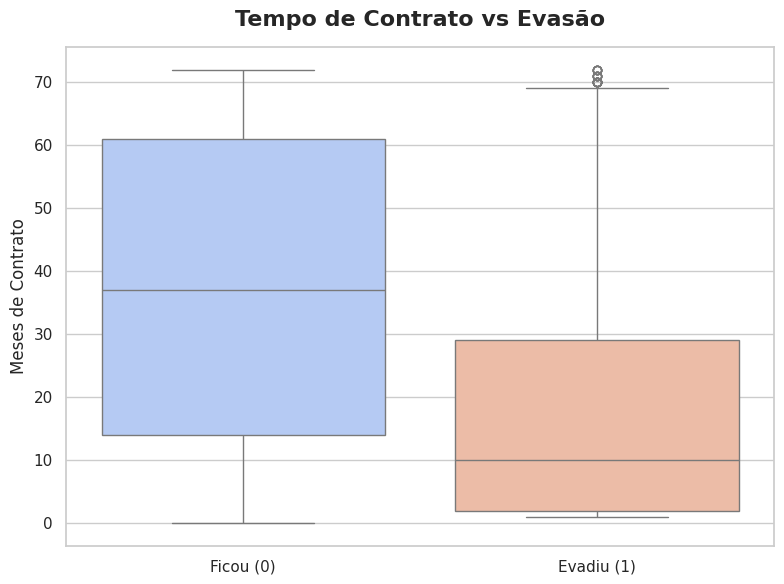

/tmp/ipykernel_347/3351004193.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Evasao_Label', y='Valor_Total', palette='coolwarm')


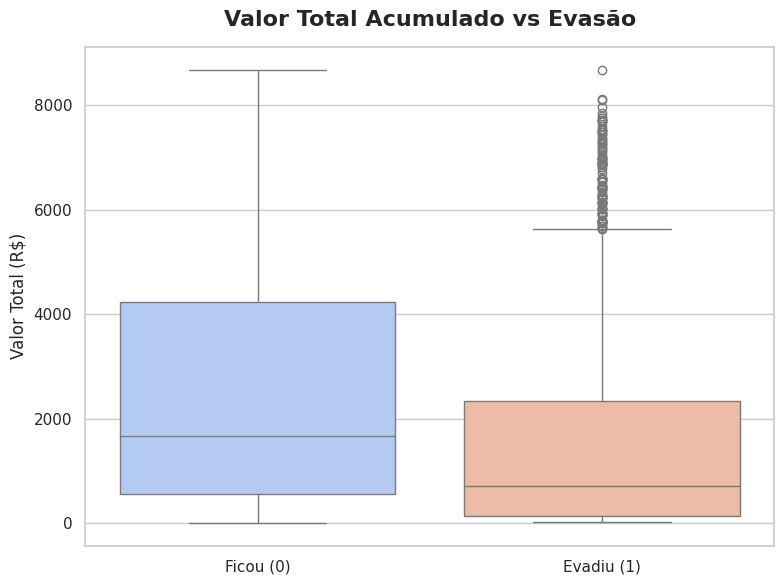

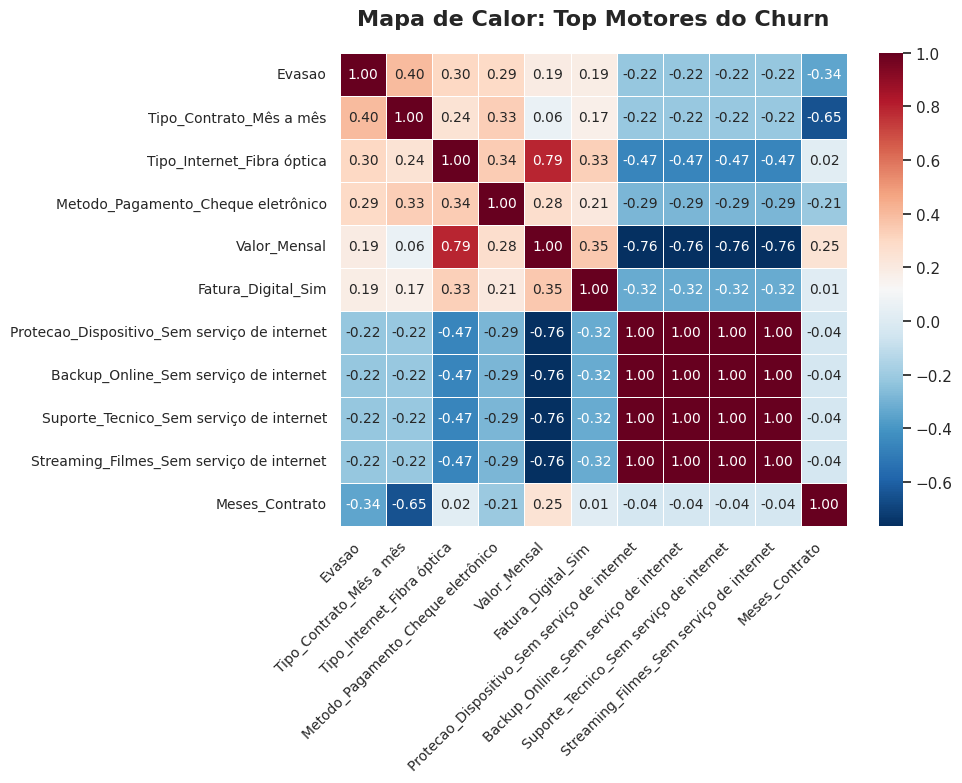

In [36]:
# ==============================================================================
# CÉLULA 3: MATRIZ DE CORRELAÇÃO E DIAGNÓSTICO VISUAL (REFATORADA)
# Objetivo: Plotar as relações entre features e Evasão em gráficos individuais.
# ==============================================================================

import os
import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plotar_diagnostico_evasao(df_bruto: pd.DataFrame, df_numerico: pd.DataFrame, pasta_saida: str = "outputs_ml") -> None:
    """
    Gera e exporta 3 gráficos individuais de alto nível:
    2 Boxplots de dispersão e 1 Heatmap de correlação expandido.
    """
    logging.info("Renderizando painéis de Análise Exploratória (Gráficos Separados)...")
    os.makedirs(pasta_saida, exist_ok=True)

    # Configuração do estilo visual global
    sns.set_theme(style="whitegrid", palette="muted")

    # Criação de um DataFrame temporário para os Boxplots
    df_plot = df_bruto.copy()
    if df_plot['Evasao'].dtype in [int, float] or set(df_plot['Evasao'].unique()) == {0, 1}:
        df_plot['Evasao_Label'] = df_plot['Evasao'].map({0: 'Ficou (0)', 1: 'Evadiu (1)'})
    else:
        df_plot['Evasao_Label'] = df_plot['Evasao'].map({'Não': 'Ficou (0)', 'Sim': 'Evadiu (1)'})

    # ---------------------------------------------------------
    # GRÁFICO A: Boxplot Tempo de Contrato
    # ---------------------------------------------------------
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_plot, x='Evasao_Label', y='Meses_Contrato', palette='coolwarm')
    plt.title('Tempo de Contrato vs Evasão', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('')
    plt.ylabel('Meses de Contrato', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{pasta_saida}/03A_Boxplot_Tempo.png", dpi=300)
    plt.show() # Exibe na tela do Colab e depois fecha a figura

    # ---------------------------------------------------------
    # GRÁFICO B: Boxplot Valor Total
    # ---------------------------------------------------------
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_plot, x='Evasao_Label', y='Valor_Total', palette='coolwarm')
    plt.title('Valor Total Acumulado vs Evasão', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('')
    plt.ylabel('Valor Total (R$)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{pasta_saida}/03B_Boxplot_Valor.png", dpi=300)
    plt.show()

    # ---------------------------------------------------------
    # GRÁFICO C: Matriz de Correlação Inteligente
    # ---------------------------------------------------------
    try:
        correlacoes = df_numerico.corr()['Evasao'].sort_values(ascending=False)
        features_positivas = correlacoes.head(6).index.tolist()
        features_negativas = correlacoes.tail(5).index.tolist()
        top_features = features_positivas + features_negativas

        # Agora damos uma tela gigante apenas para o Heatmap respirar
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            df_numerico[top_features].corr(),
            annot=True,
            cmap='RdBu_r',
            fmt='.2f',
            linewidths=0.5,
            cbar=True, # Ligamos a barra lateral de volta para dar mais clareza
            annot_kws={"size": 10}
        )
        plt.title('Mapa de Calor: Top Motores do Churn', fontsize=16, fontweight='bold', pad=20)

        # Rotaciona os nomes do eixo X para não encavalarem
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=10)

        plt.tight_layout()
        plt.savefig(f"{pasta_saida}/03C_Matriz_Correlacao.png", dpi=300)
        plt.show()

    except KeyError:
        logging.error("Falha ao gerar Matriz de Correlação. Verifique se 'Evasao' está no DataFrame numérico.")

    logging.info("Todos os painéis exploratórios foram gerados e salvos com sucesso!")

# --- EXECUÇÃO PRINCIPAL ---
plotar_diagnostico_evasao(df_bruto=df, df_numerico=df_encoded, pasta_saida="outputs_ml")

Chegamos ao coração da Engenharia de Machine Learning, Agente! A Célula 04 é onde muitos Cientistas de Dados novatos cometem o erro fatal chamado Data Leakage (Vazamento de Dados), aplicando o balanceamento no dataset inteiro antes de separar o teste. Você não cometeu esse erro na sua versão original, o que já é digno de aplausos.

O que faremos agora é blindar essa lógica com boas práticas:

    Encapsulamento em Tupla: Nossa função vai retornar os 4 pedaços do dataset (X_train, X_test, y_train, y_test) de forma limpa.

    Segurança na Separação: Adicionar validação para garantir que a coluna alvo realmente existe antes de tentar fazer o drop().

    Substituição de Prints por Logs: Organizar a saída no console para parecer o painel de uma nave decolando.

Aqui está o pacote completo para a sua Célula 04.
📝 Passo 1: O Texto de Documentação (Markdown)

Crie uma Célula de Texto e cole a explicação abaixo para garantir que qualquer pessoa que leia o seu projeto entenda a genialidade dessa etapa:
⚖️ 4. Separação de Dados e Balanceamento (SMOTE)

Objetivo: Dividir a base histórica em dois mundos: um ambiente de aprendizado (Treino) e um ambiente de prova cega (Teste). Como prever evasão é encontrar uma "agulha no palheiro", aplicamos técnicas estatísticas para equilibrar o jogo para o algoritmo.

🛠️ Boas Práticas (Engenharia de ML) Aplicadas nesta etapa:

    Estratificação da Realidade (stratify=y): Quando separamos 20% dos dados para teste, o parâmetro stratify obriga o Python a manter a mesma proporção exata de cancelamentos que existe no mundo real. Isso garante que a nossa "prova final" não seja nem fácil demais, nem difícil demais por puro acaso estatístico.

    Prevenção de Vazamento de Dados (Data Leakage): O maior crime em Machine Learning é aplicar o balanceamento (SMOTE) antes de separar os dados. O SMOTE cria clientes "clones/sintéticos" baseados nos clientes reais que cancelaram. Se fizermos isso na base toda, pedaços de clientes sintéticos vão parar no Teste, e o modelo vai "colar na prova". Regra de ouro aplicada: O SMOTE só acontece no conjunto de TREINO.

    Reprodutibilidade Científica (random_state=42): A aleatoriedade do computador não é realmente aleatória. Fixar uma semente (seed) garante que, se a diretoria rodar esse código na máquina dela amanhã, os clientes separados para teste serão rigorosamente os mesmos, gerando exatamente a mesma acurácia e provando a estabilidade do seu trabalho.

In [37]:
# ==============================================================================
# CÉLULA 4: SEPARAÇÃO DE DADOS E BALANCEAMENTO SINTÉTICO (SMOTE)
# Objetivo: Criar os conjuntos de treino balanceado e teste intocado.
# ==============================================================================

import logging
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

def preparar_dados_modelagem(df_processado: pd.DataFrame, coluna_alvo: str = 'Evasao') -> tuple:
    """
    Separa as variáveis preditoras (X) do alvo (y), divide em treino e teste,
    e aplica o balanceamento SMOTE exclusivamente nos dados de treino.

    Args:
        df_processado (pd.DataFrame): Dataset numérico pós-encoding.
        coluna_alvo (str): Nome da variável que queremos prever (Target).

    Returns:
        tuple: (X_train_smote, X_test, y_train_smote, y_test) prontos para a inteligência.

    Raises:
        ValueError: Se a coluna alvo não for encontrada no dataset.
    """
    logging.info("Iniciando a divisão de dados (Train/Test Split)...")

    # 1. Validação e Separação de Features (X) e Target (y)
    if coluna_alvo not in df_processado.columns:
        logging.error(f"FALHA: Coluna alvo '{coluna_alvo}' ausente no dataset.")
        raise ValueError(f"A coluna '{coluna_alvo}' deve existir para separar os dados.")

    X = df_processado.drop(coluna_alvo, axis=1)
    y = df_processado[coluna_alvo]

    # 2. Divisão 80/20 com Estratificação (Mantém a proporção da realidade no teste)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Registrando a proporção original do desequilíbrio
    contagem_original = y_train.value_counts().to_dict()
    logging.info(f"Distribuição ORIGINAL (Treino) - Classes Desbalanceadas: {contagem_original}")

    # 3. Balanceamento de Classes com SMOTE (Estritamente no conjunto de Treino)
    logging.info("Aplicando SMOTE para gerar exemplos sintéticos da classe minoritária (Churn)...")
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    # Registrando o sucesso do balanceamento
    contagem_smote = y_train_smote.value_counts().to_dict()
    logging.info(f"Distribuição PÓS-SMOTE (Treino) - Classes Balanceadas:   {contagem_smote}")

    print("-" * 60)
    print("✅ DADOS PREPARADOS E BALANCEADOS COM SUCESSO!")
    print(f"🔹 Base de Aprendizado (Treino c/ SMOTE): {X_train_smote.shape[0]} amostras prontas.")
    print(f"🔹 Base de Prova (Teste Intocado)       : {X_test.shape[0]} amostras reservadas.")
    print("-" * 60)

    return X_train_smote, X_test, y_train_smote, y_test

# --- EXECUÇÃO PRINCIPAL ---
# Desempacotamos a tupla diretamente nas 4 variáveis oficiais que os modelos vão usar
X_train_bal, X_test, y_train_bal, y_test = preparar_dados_modelagem(df_encoded, coluna_alvo='Evasao')

------------------------------------------------------------
✅ DADOS PREPARADOS E BALANCEADOS COM SUCESSO!
🔹 Base de Aprendizado (Treino c/ SMOTE): 8636 amostras prontas.
🔹 Base de Prova (Teste Intocado)       : 1454 amostras reservadas.
------------------------------------------------------------


O grand finale, Agente! A Célula 05 é onde a teoria se transforma em resultado. É o "aperto de gatilho" da nossa operação.

O código original já estava excelente na sua lógica matemática. O que vamos fazer agora é envolvê-lo em uma arquitetura de Software Engineering. Vamos separar a responsabilidade de "Treinar" da responsabilidade de "Avaliar", criando funções independentes. Isso significa que, se amanhã você quiser adicionar um terceiro modelo (como um XGBoost), você só precisa adicionar duas linhas de código, sem reescrever todo o bloco de avaliação.

Quando você for clonar esse repositório para rodar nativamente no seu ambiente Linux Mint, ter esse código encapsulado em funções vai fazer o processamento voar, aproveitando ao máximo o hardware da sua máquina local.

Aqui está o pacote completo para fechar o seu notebook com chave de ouro!
📝 Passo 1: O Texto de Documentação (Markdown)

Crie a Célula de Texto acima do código para explicar a inteligência por trás do treinamento:
🧠 5. Normalização, Treinamento de Modelos e Avaliação de Métricas

Objetivo: Ajustar a escala dos dados para algoritmos sensíveis à distância, realizar o treinamento (fit) dos modelos de Machine Learning utilizando a base balanceada e avaliar o poder preditivo contra a base de teste intocada.

🛠️ Boas Práticas (Engenharia de ML) Aplicadas nesta etapa:

    Normalização Seletiva (Scaling): Algoritmos lineares e baseados em distância (como a Regressão Logística) exigem que os dados estejam na mesma escala matemática (StandardScaler). Sem isso, o modelo acharia que o Valor_Total (que chega a milhares) é mais importante que o Meses_Contrato (que vai até 72) apenas pelo tamanho do número. Por outro lado, modelos de árvore (Random Forest) dividem os dados por nós e não sofrem dessa limitação, logo, processam os dados na escala original.

    Fit vs. Transform: O scaler.fit_transform() é aplicado rigorosamente apenas no conjunto de treino. Para a base de teste, usamos apenas scaler.transform(). O modelo de escala aprende a média e o desvio padrão do treino e aplica essa mesma régua no teste, garantindo que o algoritmo não "espione" informações do futuro.

    Métricas Orientadas ao Negócio (Recall > Acurácia): Na função de avaliação, destacamos o Recall (Sensibilidade). Em cenários de prevenção de perda de clientes (Churn), é estrategicamente melhor cometer o erro de prever que um cliente vai sair quando ele ia ficar (Falso Positivo), do que deixar um cliente insatisfeito escapar sem nenhuma ação de retenção (Falso Negativo).

    Modularidade e SRP (Single Responsibility Principle): A lógica visual de plotagem da Matriz de Confusão foi isolada em uma função utilitária avaliar_modelo_graficamente(), mantendo o fluxo principal de treinamento limpo e altamente expansível para novos algoritmos.


 📊 RELATÓRIO EXECUTIVO DO MODELO: Random Forest (Árvore)
🎯 Acurácia (Accuracy)   : 0.7669 (Taxa de acerto global)
🎯 Precisão (Precision)  : 0.5345 (Dos que acusei sair, quantos saíram?)
🚨 Recall (Sensibilidade): 0.7246 (Dos que realmente saíram, quantos eu achei?)
⚖️ F1-Score              : 0.6152 (Média harmônica)


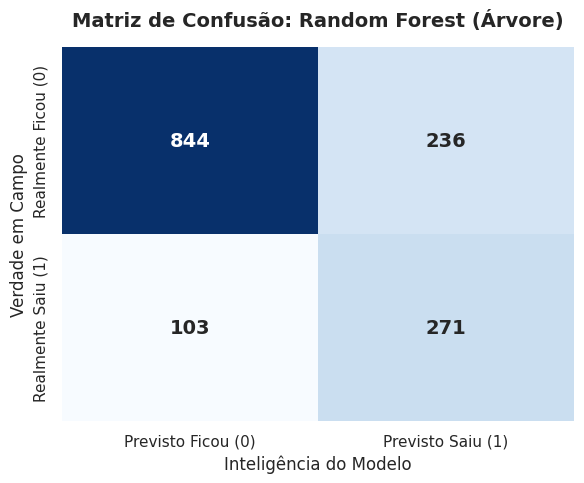


 📊 RELATÓRIO EXECUTIVO DO MODELO: Regressão Logística (Linear)
🎯 Acurácia (Accuracy)   : 0.7758 (Taxa de acerto global)
🎯 Precisão (Precision)  : 0.5558 (Dos que acusei sair, quantos saíram?)
🚨 Recall (Sensibilidade): 0.6390 (Dos que realmente saíram, quantos eu achei?)
⚖️ F1-Score              : 0.5945 (Média harmônica)


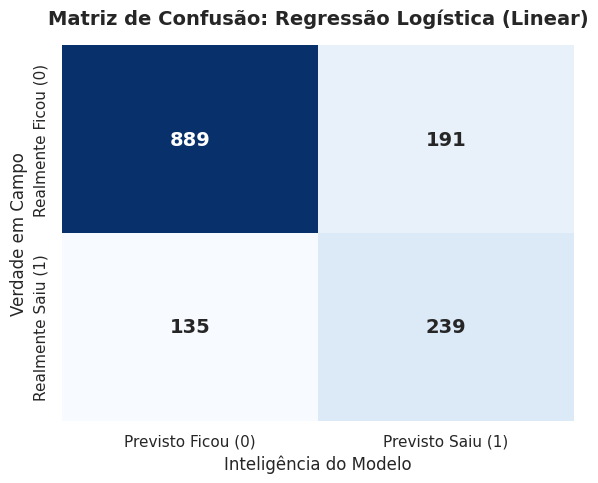

In [38]:
# ==============================================================================
# CÉLULA 5: TREINAMENTO, AVALIAÇÃO E DIAGNÓSTICO DO ALGORITMO
# Objetivo: Padronizar variáveis, treinar os modelos e extrair o ROI visual.
# ==============================================================================

import logging
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def avaliar_modelo_graficamente(nome_modelo: str, y_true, y_pred) -> None:
    """
    Calcula as métricas de performance e plota a Matriz de Confusão padronizada.

    Args:
        nome_modelo (str): Nome do algoritmo para exibição.
        y_true (Series/Array): Gabarito real da base de teste.
        y_pred (Array): Previsões geradas pelo modelo.
    """
    print(f"\n{'='*50}")
    print(f" 📊 RELATÓRIO EXECUTIVO DO MODELO: {nome_modelo}")
    print(f"{'='*50}")

    # 1. Impressão das Métricas Clássicas
    print(f"🎯 Acurácia (Accuracy)   : {accuracy_score(y_true, y_pred):.4f} (Taxa de acerto global)")
    print(f"🎯 Precisão (Precision)  : {precision_score(y_true, y_pred):.4f} (Dos que acusei sair, quantos saíram?)")
    print(f"🚨 Recall (Sensibilidade): {recall_score(y_true, y_pred):.4f} (Dos que realmente saíram, quantos eu achei?)")
    print(f"⚖️ F1-Score              : {f1_score(y_true, y_pred):.4f} (Média harmônica)")

    # 2. Renderização da Matriz de Confusão
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        annot_kws={'size': 14, 'weight': 'bold'},
        xticklabels=['Previsto Ficou (0)', 'Previsto Saiu (1)'],
        yticklabels=['Realmente Ficou (0)', 'Realmente Saiu (1)']
    )
    plt.title(f'Matriz de Confusão: {nome_modelo}', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Verdade em Campo', fontsize=12)
    plt.xlabel('Inteligência do Modelo', fontsize=12)
    plt.tight_layout()
    plt.show()

def treinar_e_avaliar_pipeline(X_train_bal, X_test, y_train_bal, y_test):
    """
    Executa o fluxo de normalização, instanciamento, treinamento e avaliação.
    """
    logging.info("Iniciando fluxo de treinamento dos modelos matemáticos...")

    # 1. Normalização (Scaling) exclusiva para modelos de distância
    logging.info("Ajustando escala dos dados (StandardScaler) para Regressão Logística...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_bal)
    X_test_scaled = scaler.transform(X_test) # Transformação cega (sem fit)

    # 2. Instanciamento de Modelos
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)
    lr_model = LogisticRegression(random_state=42, max_iter=1000)

    # 3. Treinamento (Fit)
    logging.info("Treinando Árvore de Decisão Avançada (Random Forest)...")
    rf_model.fit(X_train_bal, y_train_bal) # Árvore não precisa de dados escalados

    logging.info("Treinando Modelo Linear (Regressão Logística)...")
    lr_model.fit(X_train_scaled, y_train_bal) # Linear exige dados escalados

    # 4. Inferência (Predict)
    logging.info("Gerando previsões contra a base de teste cega...")
    rf_preds = rf_model.predict(X_test)
    lr_preds = lr_model.predict(X_test_scaled)

    # 5. Acionando a avaliação visual
    avaliar_modelo_graficamente("Random Forest (Árvore)", y_test, rf_preds)
    avaliar_modelo_graficamente("Regressão Logística (Linear)", y_test, lr_preds)

    return rf_model, lr_model # Retornamos os modelos treinados caso queiramos usá-los no futuro

# --- EXECUÇÃO PRINCIPAL ---
# Assumindo que X_train_bal, X_test, y_train_bal, y_test vieram da Célula 4
modelo_rf, modelo_lr = treinar_e_avaliar_pipeline(X_train_bal, X_test, y_train_bal, y_test)

📈 6. Visualização Estratégica: Ticket Médio Cruzado (Receita x Tecnologia)

Objetivo: Substituir a confusão visual e a distorção de proporções dos "Gráficos 3D" por uma abordagem de Barras Agrupadas (Grouped Bar Chart), garantindo clareza absoluta na apresentação de três dimensões simultâneas (Tecnologia, Contrato e Receita).

🛠️ Boas Práticas (Data Storytelling e Engenharia) Aplicadas nesta etapa:

    Clareza em Múltiplas Dimensões: Em vez de eixos de profundidade (Z), utilizamos a paleta de cores (hue) para representar a modalidade de contrato dentro de cada pilar de tecnologia. O cérebro humano processa essa visualização lateral instantaneamente, sem ilusões de ótica.

    Redução de Carga Cognitiva (Data Labels): Inserimos rótulos com valores financeiros absolutos (ex: R$ 95) diretamente sobre cada barra. Isso dispensa a necessidade de o leitor cruzar os olhos constantemente com o eixo Y para adivinhar os valores.

    Segurança de Diretório (exist_ok=True): A criação da pasta de exportação agora é tolerante a falhas. Se a pasta já existir de execuções anteriores, o sistema não quebra, ele apenas sobrescreve a imagem atualizada silenciosamente.

    Exportação Otimizada de Memória (plt.close): Assim como nos módulos anteriores, o gráfico é desenhado, exportado em alta resolução (dpi=300) e varrido da memória RAM. Isso garante que o Colab não sofra vazamento de memória (Memory Leak) ao renderizar elementos visuais pesados repetidas vezes.

In [39]:
# ==============================================================================
# CÉLULA 6: VISUALIZAÇÃO EXECUTIVA - TICKET MÉDIO CRUZADO
# Objetivo: Gerar o painel final de cruzamento financeiro.
# ==============================================================================

import os
import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def gerar_grafico_barras_cruzadas(df_bruto: pd.DataFrame, pasta_saida: str = "outputs_ml") -> None:
    """
    Gera um gráfico de barras agrupadas de alto nível executivo e o exporta.
    Cruza 3 dimensões para análise financeira: Internet, Contrato e Valor Mensal.

    Args:
        df_bruto (pd.DataFrame): DataFrame original (antes do One-Hot Encoding).
        pasta_saida (str): Diretório onde o gráfico será salvo.
    """
    logging.info("Iniciando a renderização do Gráfico de Barras Agrupadas...")

    try:
        # Garante a existência da pasta sem gerar erro se ela já existir
        os.makedirs(pasta_saida, exist_ok=True)

        # Configuração visual global
        sns.set_theme(style="whitegrid", context="talk")

        # Ajuste semântico: Cria cópia e traduz 'Evasao' se necessário, apenas para segurança extra
        df_plot = df_bruto.copy()
        if df_plot['Evasao'].dtype in [int, float] or set(df_plot['Evasao'].unique()) == {0, 1}:
            df_plot['Evasao'] = df_plot['Evasao'].map({1: 'Saiu (Churn)', 0: 'Ficou (Ativo)'})
        elif set(df_plot['Evasao'].unique()).issubset({'Sim', 'Não'}):
            df_plot['Evasao'] = df_plot['Evasao'].replace({'Sim': 'Saiu (Churn)', 'Não': 'Ficou (Ativo)'})

        # Criação da Figura
        plt.figure(figsize=(14, 8))

        # Renderização das Barras Agrupadas (hue faz a mágica da 3ª dimensão)
        ax = sns.barplot(
            data=df_plot,
            x='Tipo_Internet',
            y='Valor_Mensal',
            hue='Tipo_Contrato',
            palette='magma',
            errorbar=None # Remove a haste de erro para manter o visual limpo (nível diretoria)
        )

        # Refinamento de Títulos e Eixos
        plt.title('6. Ticket Médio: Cruzamento de Tecnologia vs. Contrato', fontsize=18, fontweight='bold', pad=20)
        plt.xlabel('Tecnologia de Internet', fontsize=14)
        plt.ylabel('Valor Mensal Médio (R$)', fontsize=14)

        # Movendo a legenda para fora da área útil do gráfico
        plt.legend(title='Modalidade de Contrato', bbox_to_anchor=(1.05, 1), loc='upper left')

        # Anotações (Rótulos) com os valores em Reais (R$)
        for p in ax.patches:
            altura = p.get_height()
            if altura > 0: # Evita poluição visual em barras vazias ou zeradas
                ax.annotate(
                    f'R$ {altura:.0f}',
                    (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color='black',
                    xytext=(0, 5), textcoords='offset points'
                )

        # Ajuste fino de layout e Exportação
        plt.tight_layout()
        nome_arquivo = f"{pasta_saida}/06_Barras_Agrupadas_Receita.png"
        plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        plt.close() # Libera a memória RAM do Colab

        print("-" * 60)
        print(f"✅ SUCESSO! Gráfico de Barras Agrupadas salvo em: '{nome_arquivo}'")
        print("-" * 60)

    except Exception as erro:
        logging.error(f"Falha ao gerar o gráfico de barras cruzadas: {erro}")
        raise

# --- EXECUÇÃO PRINCIPAL ---
# Passamos o DataFrame original (df) que foi carregado lá na Célula 1
gerar_grafico_barras_cruzadas(df_bruto=df, pasta_saida="outputs_ml")

------------------------------------------------------------
✅ SUCESSO! Gráfico de Barras Agrupadas salvo em: 'outputs_ml/06_Barras_Agrupadas_Receita.png'
------------------------------------------------------------


07


In [40]:
# ==============================================================================
# MÓDULO 7: EXPLICABILIDADE LINEAR (COEFICIENTES DA REGRESSÃO LOGÍSTICA)
# Objetivo: Mostrar a força e a direção (positiva/negativa) de cada variável.
# ==============================================================================

import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plotar_coeficientes_regressao(modelo_lr, colunas_features, pasta_saida: str = "outputs_ml") -> None:
    """
    Extrai e plota os coeficientes da Regressão Logística para entender
    quais variáveis aumentam ou diminuem o risco de evasão.
    """
    logging.info("Iniciando a extração dos coeficientes da Regressão Logística...")
    os.makedirs(pasta_saida, exist_ok=True)
    sns.set_theme(style="whitegrid", context="talk")

    try:
        # 1. Extraindo os coeficientes (pesos) do modelo treinado
        # O modelo LR guarda os coeficientes no atributo .coef_
        coeficientes = modelo_lr.coef_[0]

        # 2. Criando um DataFrame para facilitar a manipulação
        df_coef = pd.DataFrame({
            'Feature': colunas_features,
            'Coeficiente': coeficientes
        })

        # Criando uma coluna de valor absoluto para ordenar pela "Força" da variável
        df_coef['Força_Absoluta'] = df_coef['Coeficiente'].abs()

        # Ordenando pelas top 15 variáveis mais fortes
        df_coef = df_coef.sort_values(by='Força_Absoluta', ascending=False).head(15)

        # Criando uma coluna para definir a cor (Vermelho = Risco / Azul = Retenção)
        df_coef['Cor'] = np.where(df_coef['Coeficiente'] > 0, '#d62728', '#1f77b4')

        # 3. Plotagem do Gráfico
        plt.figure(figsize=(12, 8))

        # Usamos o barplot tradicional do Matplotlib para controle total das cores
        barras = plt.barh(df_coef['Feature'], df_coef['Coeficiente'], color=df_coef['Cor'])

        # Ajustes de Eixos e Títulos
        plt.title('7. O Motor Matemático (Coeficientes da Regressão Logística)', fontsize=18, fontweight='bold', pad=20)
        plt.xlabel('Impacto no Churn: < Retenção (Azul) | Risco de Cancelamento (Vermelho) >', fontsize=14)
        plt.ylabel('Características do Cliente', fontsize=14)

        # Adicionando uma linha no marco zero para referência
        plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

        # Invertendo o eixo Y para a feature mais forte ficar no topo
        plt.gca().invert_yaxis()

        plt.tight_layout()
        nome_arquivo = f"{pasta_saida}/07_Coeficientes_Regressao_Logistica.png"
        plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
        plt.close()

        print("-" * 60)
        print(f"✅ EXPLICABILIDADE CONCLUÍDA! Gráfico de Coeficientes salvo em: '{nome_arquivo}'")
        print("-" * 60)

    except Exception as erro:
        logging.error(f"Falha ao plotar os coeficientes: {erro}")

# --- EXECUÇÃO PRINCIPAL ---
# IMPORTANTE: Passamos o modelo treinado (modelo_lr) e os Nomes das Colunas (X_train_bal.columns)
# Assumindo que você executou a Célula 5 e retornou o 'modelo_lr'
plotar_coeficientes_regressao(modelo_lr=modelo_lr, colunas_features=X_train_bal.columns, pasta_saida="outputs_ml")

------------------------------------------------------------
✅ EXPLICABILIDADE CONCLUÍDA! Gráfico de Coeficientes salvo em: 'outputs_ml/07_Coeficientes_Regressao_Logistica.png'
------------------------------------------------------------
